# Practical 1

The main aim of this practical is for you to automate the Bayesian assimilation loop for the single pendulum system that
was discussed within lecture 1. Having done this, you will reconstruct the system's dynamics over the observation period.
In doing all this, you will be able to vary the number and accuracy of the observations, and also change the prior on the
initial condition. In this manner, you can investigate the sensitivity of the results of the assimilation problem to
these parameters.

First we import the necessary libraries:

In [1]:
# Import the necessary libraries for this notebook,
# installing pygeoinf if required.
try:
    from pygeoinf import data_assimilation as da
except ImportError:
    %pip install pygeoinf --quiet
    from pygeoinf import data_assimilation as da

import numpy as np
import matplotlib.pyplot as plt
from pygeoinf.data_assimilation.pendulum import single

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.3/145.3 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.0/519.0 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.9/37.9 MB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 MB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 62.9 MB/s eta 0:00:00


The code block below sets up the assimilation problem and generates synthetic data for us to use. Initially you should just run this code, but later you can modify it, changing various parameters such as the number of observations or the error statistics.  

Generating synthetic data...


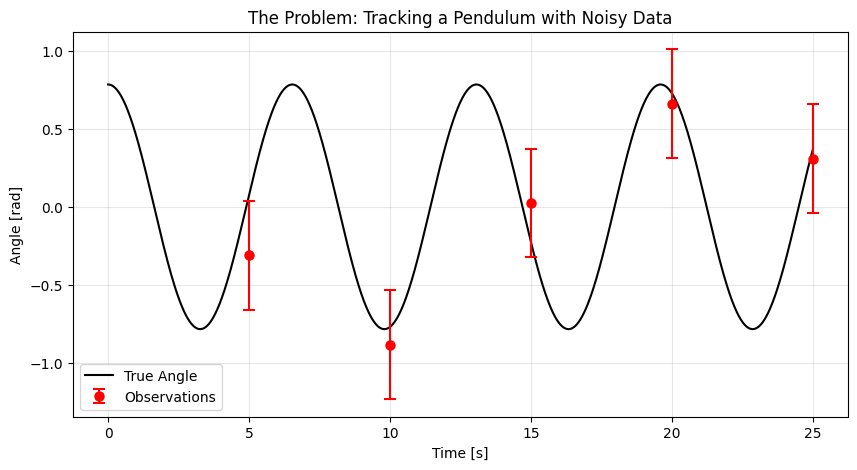

In [2]:
# Initial Condition
# TODO -- vary the initial conditions
true_y0 = np.array([np.deg2rad(45), 0.0])

# Create the Assimilation Problem Manager
problem = da.BayesianAssimilationProblem(eom_func=single.eom)

# Define Observations
# TODO -- vary the number and spacing of the observations
n_obs = 5
dt_obs = 5

t_obs_points = np.linspace(
    dt_obs,
    dt_obs*n_obs,
    n_obs
)

# TODO -- vary the observational error. The error
#         stats could change per observation.
obs_error_sigma = np.deg2rad(10.0)
R = np.array([[obs_error_sigma**2]])

# Observation Operator for theta
H = np.array([[1.0, 0.0]])

# Register these observations with the problem
print("Generating synthetic data...")
for t in t_obs_points:
    problem.add_observation(
        time=t, covariance=R, operator=H, value=None
    )

# 5. Generate the "Truth" and the Noisy Data
truth_data = problem.generate_synthetic_data(
    true_initial_condition=true_y0,
    dt_render=0.01
)

# Visualise the Problem
t_true = truth_data["t_ground_truth"]
y_true = truth_data["state_ground_truth"]
obs_list = problem.observations  # List of (time, model) tuples

plt.figure(figsize=(10, 5))
plt.plot(t_true, y_true[0], "k-", label="True Angle")

# Extract observation values for plotting
t_vals = [t for t, _ in obs_list]
y_vals = [m.y_obs[0] for _, m in obs_list]

plt.errorbar(
    t_vals, y_vals,
    yerr=2*obs_error_sigma,
    fmt='ro',
    capsize=4,
    elinewidth=1.5,
    markeredgewidth=1.5,
    label='Observations'
)

plt.xlabel("Time [s]")
plt.ylabel("Angle [rad]")
plt.title("The Problem: Tracking a Pendulum with Noisy Data")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## Part 1 - Implementing the assimilation loop

In [10]:
import inspect
print(inspect.getsource(da.LinearGaussianLikelihood))

class LinearGaussianLikelihood(GaussianLikelihood):
    """
    Optimised subclass for Linear Observation Operators: y = Hx
    Avoids generic function calls in favour of matrix multiplication.
    """

    def __init__(
        self,
        observation_value: Optional[np.ndarray],
        observation_covariance: np.ndarray,
        observation_matrix: np.ndarray,
    ):
        """
        Args:
            observation_value: The observed data vector 'y_obs' (ObsDim,).
            observation_covariance: The observation error covariance matrix 'R'.
            observation_matrix: The observation matrix H (ObsDim, StateDim).
        """
        self.H_mat = np.atleast_2d(observation_matrix)

        def linear_op(x):
            return x @ self.H_mat.T

        super().__init__(observation_value, observation_covariance, linear_op)

    def evaluate(self, prob_grid: ProbabilityGrid) -> ProbabilityGrid:
        """Optimised evaluation for linear H."""
        if self.y_obs is None:
    

In [16]:
# Set the bounds for the probability grid
# TODO -- the size or resolution of the grid can be varied
#         higher resolutions will require more computations
bounds = [(-np.pi, np.pi), (-5, 5)]
resolution = [300,300]

# Set the prior on the initial conditions
# TODO -- this choice can be varied
prior_mean = [0.0, 0.0]
prior_cov = np.diag([0.5**2, 0.5**2])

prior_pdf = da.get_gaussian_pdf(prior_mean, prior_cov)
initial_prior_grid = da.ProbabilityGrid.from_bounds(
    bounds,
    resolution,
    prior_pdf
)


# --- Step C: The Loop (TODO) ---

# initialise some variables
current_grid = initial_prior_grid
manual_history = []
t_current = 0.0

# Loop through the raw observation times and values
# Loop through the raw observation times and values
# Loop through the raw observation times and values
for t_obs, y_observed in zip(t_vals, y_vals):

    # 1. Calculate time step to the next observation
    dt = t_obs - t_current

    # Reset variables to None at the start of each iteration
    # This ensures we don't accidentally reuse values from the previous loop
    forecast_grid = None
    analysis_grid = None
    evidence = None

    # ============================================================
    # TODO: YOUR CODE HERE
    # ============================================================


    # --- TODO TASK 1: FORECAST (The Prior for this step) ---
    # Evolve 'current_grid' forward by dt to create the 'forecast_grid'.
    # Hint: Use current_grid.push_forward(...). You will need to provide
    # the dynamic rule for the system which is stored in 'problem.eom_func'

    forecast_grid = current_grid.push_forward(problem.eom_func, dt)


# --- TODO TASK 2: OBSERVE (The Likelihood) ---



    lik_model = da.LinearGaussianLikelihood(
    np.array([y_observed]),   # 1. observation_value  (ObsDim,)
    R,                  # 2. observation_covariance
    H                   # 3. observation_matrix
    )

    print("H_mat shape stored:", lik_model.H_mat.shape)
    # 3. Evaluate on the grid
    lik_grid = lik_model.evaluate(forecast_grid)

    # --- TODO TASK 3: ANALYSIS (Bayes' Theorem) ---
    # We want: Posterior = (Prior * Likelihood) / Evidence

    # A. Calculate the unnormalised posterior (Numerator)
    # Hint: ProbabilityGrid supports element-wise multiplication using '*'

    unnorm_posterior = forecast_grid * lik_grid


    # B. Calculate the Evidence (Denominator)
    # This is the total probability mass (integral) of the unnormalised grid.
    # Hint: ProbabilityGrid has a property 'total_mass' that returns the
    #       necessary integral approximated using quadrature

    evidence = unnorm_posterior.total_mass


    # C. Calculate the Final Posterior (Normalisation)
    # Divide the unnormalised grid by the evidence.

    analysis_grid = unnorm_posterior / evidence

    # Update for the next iteration
    current_grid = analysis_grid
    t_current = t_obs
    manual_history.append({'time': t_obs, 'forecast': forecast_grid, 'analysis': analysis_grid})


    # ============================================================
    # END YOUR CODE
    # ============================================================


H_mat shape stored: (1, 2)
H_mat shape stored: (1, 2)
H_mat shape stored: (1, 2)
H_mat shape stored: (1, 2)
H_mat shape stored: (1, 2)


The code block below plots the posterior at the final observation time you have determined, and compares it to the result
that is automated within the `BayesianAssimilationProblem` class through its method `run`. If your implmentation
is correct, the two PDFs should look identical.

Once the two PDFs agreee, you can go back and vary the observations and priors within the problem to qualitatively assess their
impact. A particularly important question is the dependence on the initial prior. What happens if the prior is consistent with
the true initial conditoins - that we can't know in real applications. If we have enough data, does the choice of prior become
unimportant?


Running automated verification...


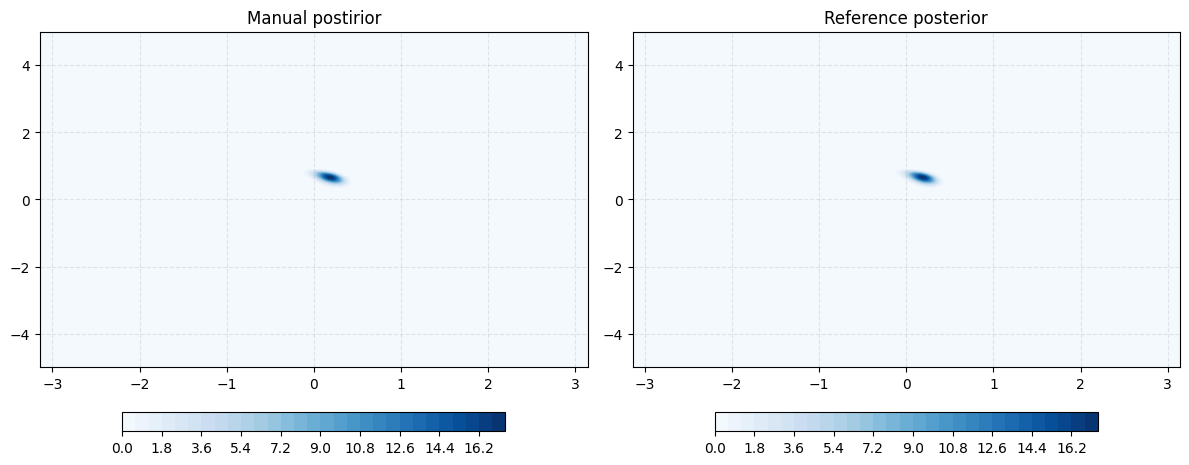


Max difference between grids: 5.32907e-15
SUCCESS: Your manual implementation matches the reference!


In [13]:
print("\nRunning automated verification...")
automated_history = problem.run(initial_prior_grid)

# 2. Compare the Final Posteriors
#    We will plot your manual result vs the automated result side-by-side.
manual_final = manual_history[-1]['analysis']
auto_final = automated_history[-1]['analysis']
final_time = t_vals[-1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot Manual
_, c1 =  da.plot_grid_marginal(
            manual_final,
            dims=(0,1),
            ax=axes[0],
            cmap="Blues"
        )

# Plot Automated
_, c2 = da.plot_grid_marginal(
            auto_final,
            dims=(0,1),
            ax=axes[1],
            cmap="Blues"
        )


titles = ["Manual postirior", "Reference posterior" ]
for ax, title, c in zip(axes, titles, [c1,c2]):
    ax.set_title(title)
    fig.colorbar(c, ax=ax, location="bottom", shrink=0.7, pad=0.1)

plt.tight_layout()
plt.show()

# Verification Check
diff = np.max(np.abs(manual_final.values - auto_final.values))
print(f"\nMax difference between grids: {diff:.5e}")
if diff < 1e-5:
    print("SUCCESS: Your manual implementation matches the reference!")
else:
    print("WARNING: Your implementation differs from the reference.")

## Part 2 - Reconstructing the dynamics

You can now estimate the posterior distribution at the final observation time. This PDFs could be pushed forward to any later time to arrive at a forecast. Here, however, we will focus on **reanalysis** of the dynamics. As discussed in the lectures, this means pushing back the final posterior to the initial time to arrive at an
update on the initial state. The posterior on the intiial state can then be used to reconstruct the systems complete dynamics over the observation period.

Your first aim it to obtain and visualise the posterior PDF of the initial state. Having done this, you can then sample values from this distribution, and for each sample calculate the corresponding trajectory. These sampled trajectories for both $\theta$ and $p$ should be plotted as time series, with the $theta$ observations shown on the first plot.

In [32]:
print(len(t_true))
traj = da.solve_trajectory(problem.eom_func,10, t_true[-1])
print(len(traj))

2501


IndexError: invalid index to scalar variable.


Running reanalysis...


/usr/local/lib/python3.12/dist-packages/pygeoinf/data_assimilation/core.py:1242: UserWarning: The following kwargs were not used by contour: 'color', 'label'
  contour = ax.contourf(X, Y, Z, **kwargs)


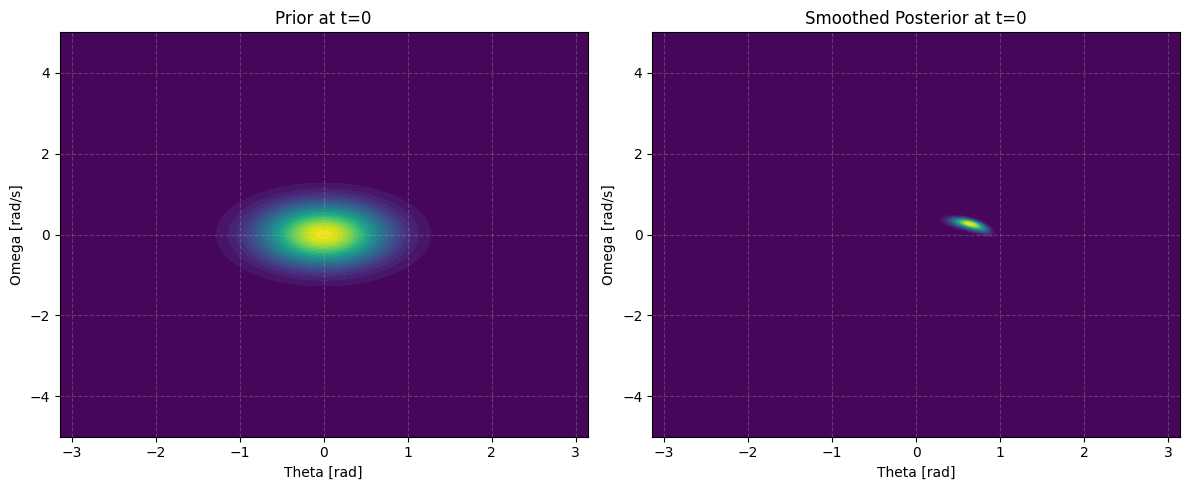

Sampling and reconstructing trajectories...


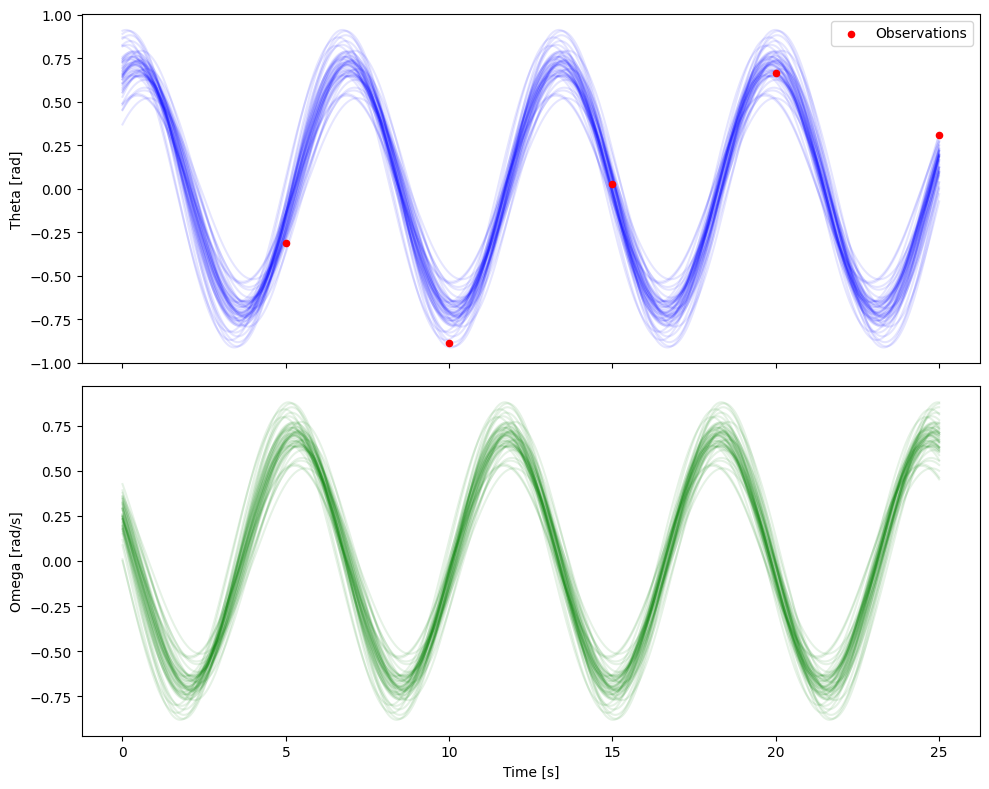

In [34]:
print("\nRunning reanalysis...")

# --- STEP 1: Obtain the Smoothed Initial Distribution ---
manual_final = manual_history[-1]['analysis']
final_time = manual_history[-1]['time']
initial_posterior_grid = manual_final.push_forward(problem.eom_func, -final_time)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot the full 2D joint distribution (theta vs omega)
da.plot_grid_marginal(initial_prior_grid,     ax=axes[0], color='gray', label='Prior (t=0)')
da.plot_grid_marginal(initial_posterior_grid, ax=axes[1], color='blue', label='Smoothed (t=0)')

axes[0].set_title("Prior at t=0")
axes[0].set_xlabel("Theta [rad]")
axes[0].set_ylabel("Omega [rad/s]")

axes[1].set_title("Smoothed Posterior at t=0")
axes[1].set_xlabel("Theta [rad]")
axes[1].set_ylabel("Omega [rad/s]")

plt.tight_layout()
plt.show()
# --- STEP 3: Reconstruct Trajectories ---
print("Sampling and reconstructing trajectories...")
n_samples = 50
samples = initial_posterior_grid.sample(n_samples)

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

for s in samples:
    traj = da.solve_trajectory(problem.eom_func, s, t_true)
    axes[0].plot(t_true, traj[0, :], color='blue', alpha=0.1)   # Theta
    axes[1].plot(t_true, traj[1, :], color='green', alpha=0.1)  # Omega

axes[0].scatter(t_vals, y_vals, color='red', s=20, label='Observations', zorder=5)
axes[0].set_ylabel("Theta [rad]")
axes[1].set_ylabel("Omega [rad/s]")
axes[1].set_xlabel("Time [s]")
axes[0].legend()
plt.tight_layout()
plt.show()
# ----------------

In [33]:
import inspect
print(inspect.getsource(da.solve_trajectory))

def solve_trajectory(
    eom_func: Callable[[float, np.ndarray, Any], np.ndarray],
    y0: np.ndarray,
    t_points: np.ndarray,
    args: Tuple = (),
    rtol: float = 1e-9,
    atol: float = 1e-12,
    method: str = "RK45",
) -> np.ndarray:
    """
    Integrates a single ODE trajectory over time.

    Args:
        eom_func: The Equation of Motion function f(t, y, *args) -> dy/dt.
        y0: Initial state vector of shape (n_dim,).
        t_points: Array of time points to evaluate at.
        args: Tuple of extra arguments to pass to eom_func.
        rtol: Relative tolerance for solver.
        atol: Absolute tolerance for solver.
        method: Integration method (e.g., 'RK45', 'DOP853').

    Returns:
        Solution array of shape (n_dim, n_times).
    """
    t_span = (t_points[0], t_points[-1])
    sol = solve_ivp(
        eom_func,
        t_span,
        y0,
        t_eval=t_points,
        method=method,
        rtol=rtol,
        atol=atol,
        args=args,
    )
   